In [92]:
import importlib
import model_utils

importlib.reload(model_utils)


<module 'model_utils' from '/Users/ehabhasan/Documents/Projects/Time Series Forecasting/Large Scale Forecasting/model_utils.py'>

In [ ]:
import model_utils
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Loading Data

In [94]:
train=pd.read_csv('Data/training.csv')
val=pd.read_csv('Data/valid.csv')
test=pd.read_csv('Data/testing.csv')


# Sliding Window Configuration

The following `DataWindow` instance is used to generate input-label pairs for training deep learning models on time series data. Batches are shuffled during training to improve model generalization. This windowing setup supports 24-hour-ahead forecasting and avoids overlap between training samples, ensuring temporal consistency and reducing data leakage.


In [95]:
window=model_utils.DataWindow(input_width=24,label_width=24,shift=24,train_df=train,test_df=test,val_df=val,label_columns=['Value'],shuffle=True)

# Model Benchmarking

**ModelBuilder**

`ModelBuilder` is a class that streamlines the creation of Keras models for time series forecasting. It abstracts repetitive tasks such as input handling, embedding setup, and model structure definition. Each method returns a compiled Keras model ready for training.

---

Key Features

- **Handles both numerical and categorical (country) inputs.**
- **Integrates an embedding layer for `Country` to learn dense representations.**
- **Provides easy-to-use builders for each model architecture used in benchmarking.**
- **Ensures consistent input shapes and preprocessing across models.**


In [96]:
builder = model_utils.ModelBuilder(window, train)
# Initialize dictionaries to store MAE results for each model
val_perf,test_perf={},{}

## Basline Model

### Model Architecture
==================

**Model Architecture — Baseline (Repeat)**

**How it works:**

- The baseline model does **not** learn any patterns from the data.
- For each country and each series, it simply copies the last observed values from the input window and uses them as the forecast for the next period (output window).
- This means that the prediction for the next 24 hours will simply be the last known 24 hours of data.

**Inputs:**  
- Numerical features: `[batch, input_window, features]`  
  (Usually, only the target variable is used for the baseline)

**Steps:**
1. **Select Last Values:**  
   - Take the most recent values from the input sequence (the last `label_width` timesteps).

2. **Output:**  
   - Use these as the forecast for the future.
   - Output shape: `[batch, output_window, 1]`

---

**Purpose**

The baseline model acts as a reference point. It just repeats the last known values as its predictions, without doing any learning.  
This helps you see if your more advanced models are actually learning useful patterns and improving on “just guessing the same as last time.”



In [97]:
Baseline_model, _, val_perf, test_perf = model_utils.pipeline(
    model_type='repeat_baseline',
    window=window,
    model_kwargs={'target': 'Value'},
    builder=builder,
    val_perf=val_perf,
    test_perf=test_perf
)


/opt/anaconda3/envs/ML-env1/lib/python3.10/site-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0956 - mean_absolute_error: 0.2584
Memory used for training: 167.9 MB


- The Baseline model does not adapt to trends or seasonality—its predictions are flat lines matching the last input value.

MAE=0.259


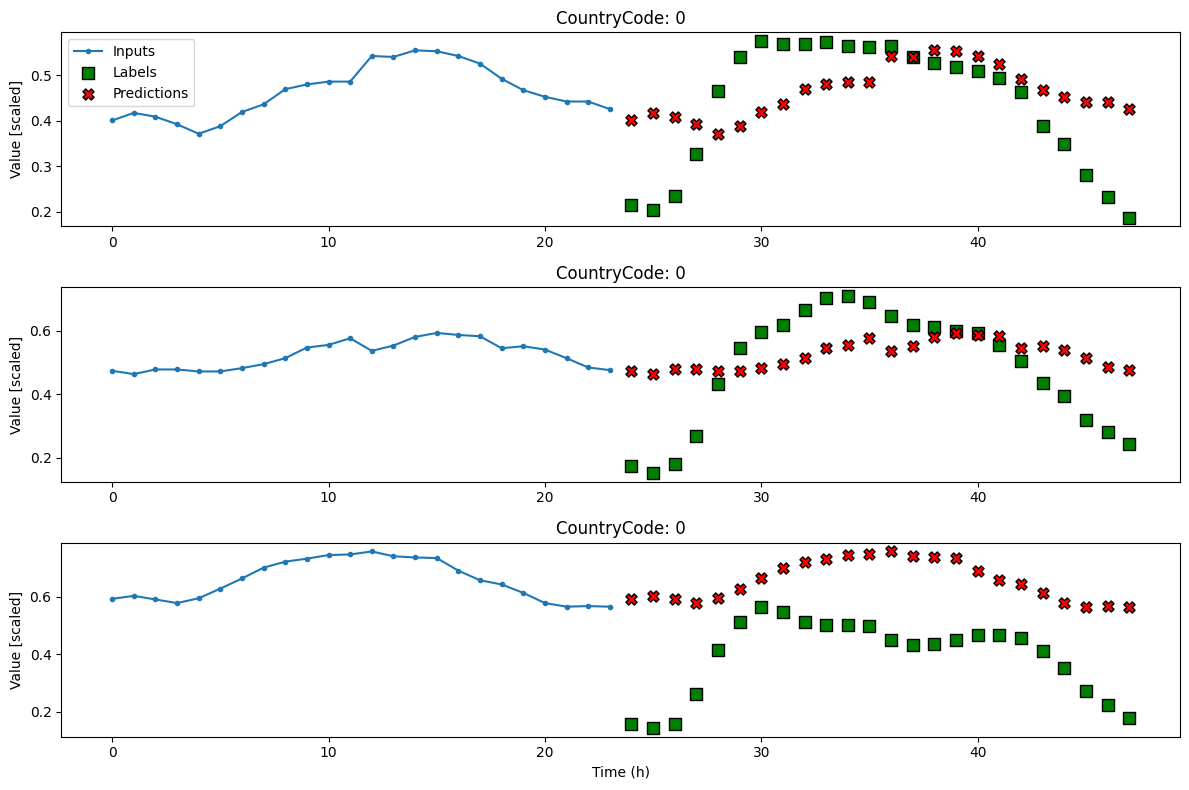

In [98]:
print(f"MAE={round(test_perf['repeat_baseline'][1],3)}")
window.plot(Baseline_model)

## Linear

### Model Architecture

**Inputs:**  
- Concatenation of all numerical features and country embeddings.
-Numerical: Tensor of shape [batch, time, features]
- Country: Tensor of shape [batch, time] (integer IDs for each country)

**Layers:**
1. **Input:**  
   - Numerical input: Shape `[batch, time, features]`
   - Country input: [batch, time] (integer-encoded)

2. **Embedding Layer:**  
   - Learns dense representation for each country code.

3. **Concatenate:**  
   - Concatenate numerical inputs with country embeddings along the feature axis for each timestep.
   - Resulting shape: [batch, time, features + embedding_dim]

4. **Dense Layer:**  
   - `Dense(1)` Applies a linear transformation (no activation function) to each timestep, predicting the regression value.

5. **Output:** 
   - A single predicted value for each timestep in the input window.
   - Shape: [batch, time, 1]

**Purpose:** 
- Establishes a strong linear baseline using both feature types.



In [99]:
linear_model, _, val_perf, test_perf= model_utils.pipeline(
    model_type='linear',
    model_kwargs={'drop_column': ['CountryCode']},
    window=window,
    builder=builder,
    val_perf=val_perf,
    test_perf=test_perf)

144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0082 - mean_absolute_error: 0.0652
Memory used for training: 303.0 MB


- The linear model uses all input features and country information to make its forecasts. Unlike the baseline, it can fit trends and shifts in the data, which is visible in the closer alignment between the predictions and the actual values.
- The linear model’s predictions track the ups and downs of the actual values, unlike the flat predictions of the baseline.
- The much lower MAE shows that even a simple linear model can provide strong improvements over naive methods in time series forecasting.

MAE=0.071


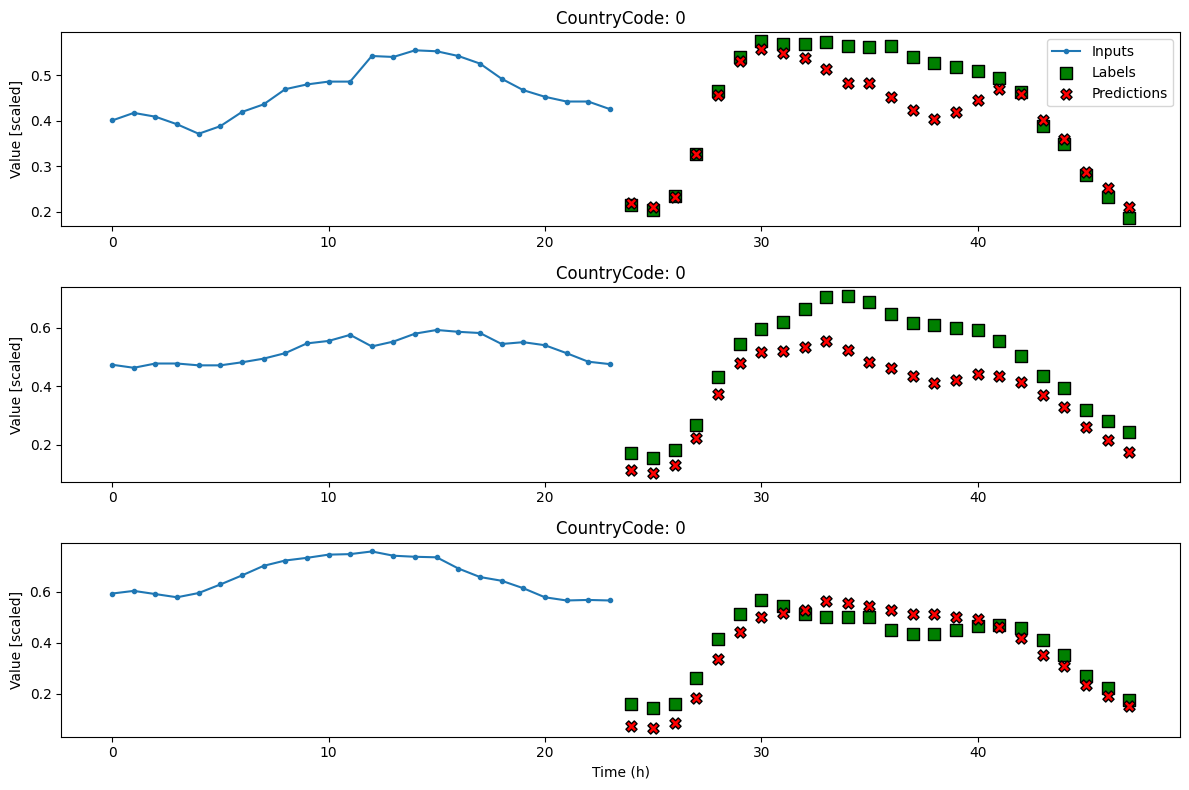

In [100]:
print(f"MAE={round(test_perf['linear'][1],3)}")
window.plot(linear_model)

## Dense/FNN (Fully Connected Neural Network)


### Model Architecture
==================

**Inputs:**  
- Concatenation of all numerical features and country embeddings.
-Numerical: Tensor of shape [batch, time, features]
- Country: Tensor of shape [batch, time] (integer IDs for each country)

**Layers:**
1. **Input:**  
   - Numerical input: Shape `[batch, time, features]`
   - Country input: [batch, time] (integer-encoded)

2. **Embedding Layer:**  
   - Learns dense representation for each country code.

3. **Concatenate:**  
   - Concatenate numerical inputs with country embeddings along the feature axis for each timestep.
   - Resulting shape: [batch, time, features + embedding_dim]

4. **Dense Layer:**  
   - `TimeDistributed(Dense(64, activation='relu'))`: This layer applies a Dense (fully connected) layer with 64 units and a ReLU activation to each timestep independently. The TimeDistributed wrapper ensures that the same dense transformation is applied to every time step in the sequence, not just once to the entire input. By stacking dense layers with nonlinear activation (ReLU), the model can learn complex, nonlinear relationships between input features at each timestep.
    - `TimeDistributed(Dense(64, activation='relu'))`: A second Dense layer (64 units, ReLU), further increasing model depth and capacity.
    - `TimeDistributed(Dense(1))`: The final output layer, with a single unit and no activation (for regression). It outputs the predicted value (e.g., electricity usage) for each time step in the sequence..

5. **Output:** 
    - `TimeDistributed(Dense(1))`: The final output layer, with a single unit and no activation (for regression). It outputs the predicted value (e.g., electricity usage) for each time step in the sequence.. 
    - Tensor of shape [batch, time, 1] — a predicted value for each timestep in the sequence.


**Purpose:**  
The Dense/FNN model captures nonlinear interactions between features at each timestep using stacked fully connected layers, leveraging both numerical and embedded categorical (country) features.

In [101]:
fnn_model, _, val_perf, test_perf= model_utils.pipeline(model_type='fnn',
                                            model_kwargs={'drop_column': ['CountryCode']},
                                            window=window,
                                            builder=builder,
                                            val_perf=val_perf,
                                            test_perf=test_perf)

144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0075 - mean_absolute_error: 0.0632
Memory used for training: 45.3 MB


- The Dense/FNN model uses two hidden Dense layers with ReLU activations, allowing it to learn more complex, nonlinear relationships in the data compared to the linear model. Its predictions generally follow the trend and magnitude of the actual values, closely tracking both sharp changes and smooth transitions.
- The Dense/FNN model can fit the shape of the target sequence more flexibly than a simple linear approach.
- Its lower MAE means it is performing well on this forecasting task, and advanced models should at least match or outperform this baseline for further gains.

MAE=0.068


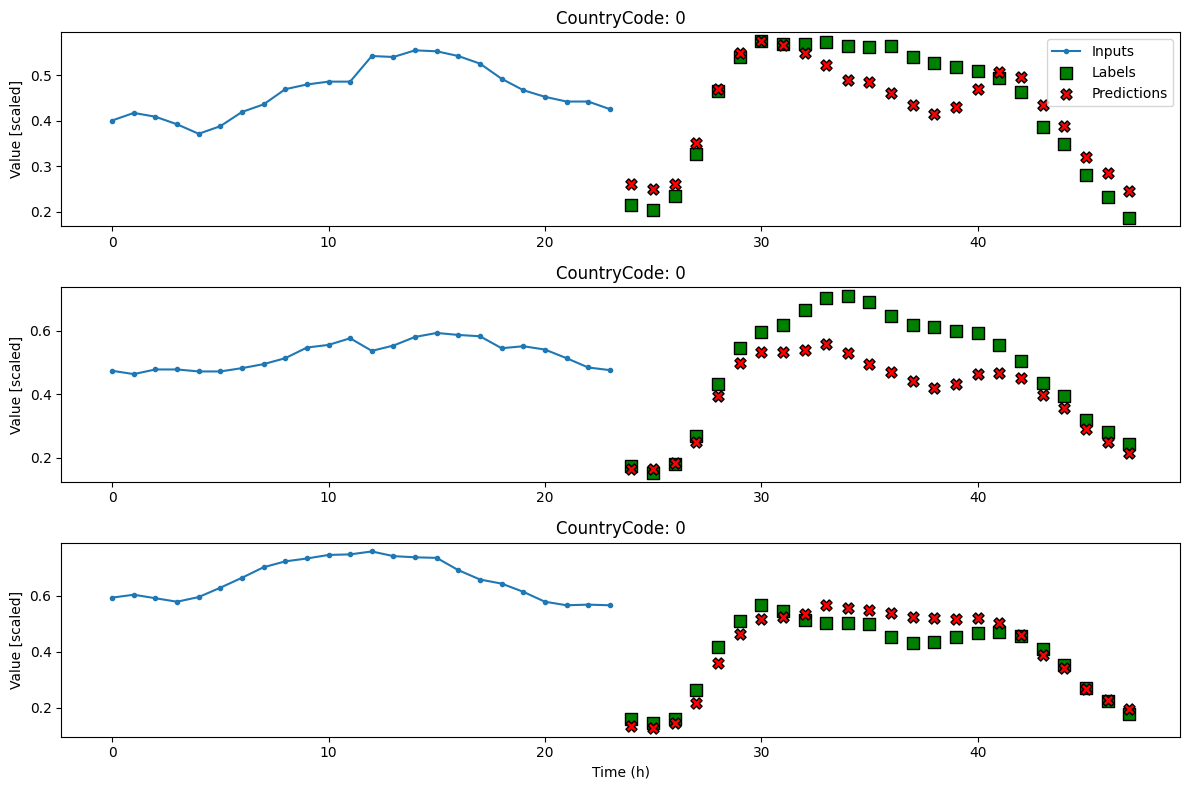

In [102]:
print(f"MAE={round(test_perf['fnn'][1],3)}")
window.plot(fnn_model)

## LSTM

### Model Architecture
==================

**Inputs:**  
- Concatenation of all numerical features and country embeddings.
-Numerical: Tensor of shape [batch, time, features]
- Country: Tensor of shape [batch, time] (integer IDs for each country)

**Layers:**
1. **Input layers:**  
   - Numerical input: Shape `[batch, time, features]`
   - Country input: [batch, time] (integer-encoded)

2. **Embedding Layer:**  
   - Learns dense representation for each country code.

3.  **Concatenate Layer:** 
    - Concatenate numerical features and country embeddings along the feature axis for each timestep.
    - Shape after concatenation: [batch, time, features + embedding_dim]

4. **LSTM Layer:**  
   - LSTM(units=32, return_sequences=True)
   - Processes the entire sequence, learning temporal dependencies and outputting a hidden state for every timestep.
   - Output shape: [batch, time, 32]
 
5. **Dense Output Layer:**
   - TimeDistributed(Dense(1, kernel_initializer=zeros))
   - Produces a single regression value per timestep.
   - Output shape: [batch, time, 1]

**Purpose:**
   - The LSTM model is designed to capture temporal dependencies and sequential patterns in the time series data. By processing the concatenated numerical features and learned country embeddings with an LSTM layer, the model can learn how past values and country-specific effects influence future predictions. This architecture is well-suited for time series forecasting tasks where patterns unfold over time and may depend on both recent and more distant observations.


In [103]:
lstm_model, _, val_perf, test_perf = model_utils.pipeline(
    model_type='lstm',
    window=window,
    model_kwargs={'drop_column': ['CountryCode']},
    builder=builder,
    val_perf=val_perf,
    test_perf=test_perf)


144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0083 - mean_absolute_error: 0.0645
Memory used for training: 36.4 MB


- The LSTM model is able to learn both short-term and long-term patterns in the sequence, thanks to its recurrent structure. In the plots, the predicted values (red crosses) follow the actual targets (green squares) very closely, including shifts and non-linear changes.
- The LSTM model achieves the lowest MAE so far, showing that capturing sequential (temporal) dependencies with a recurrent network can significantly boost forecast accuracy, especially when compared to baseline and non-sequential models.

MAE=0.068


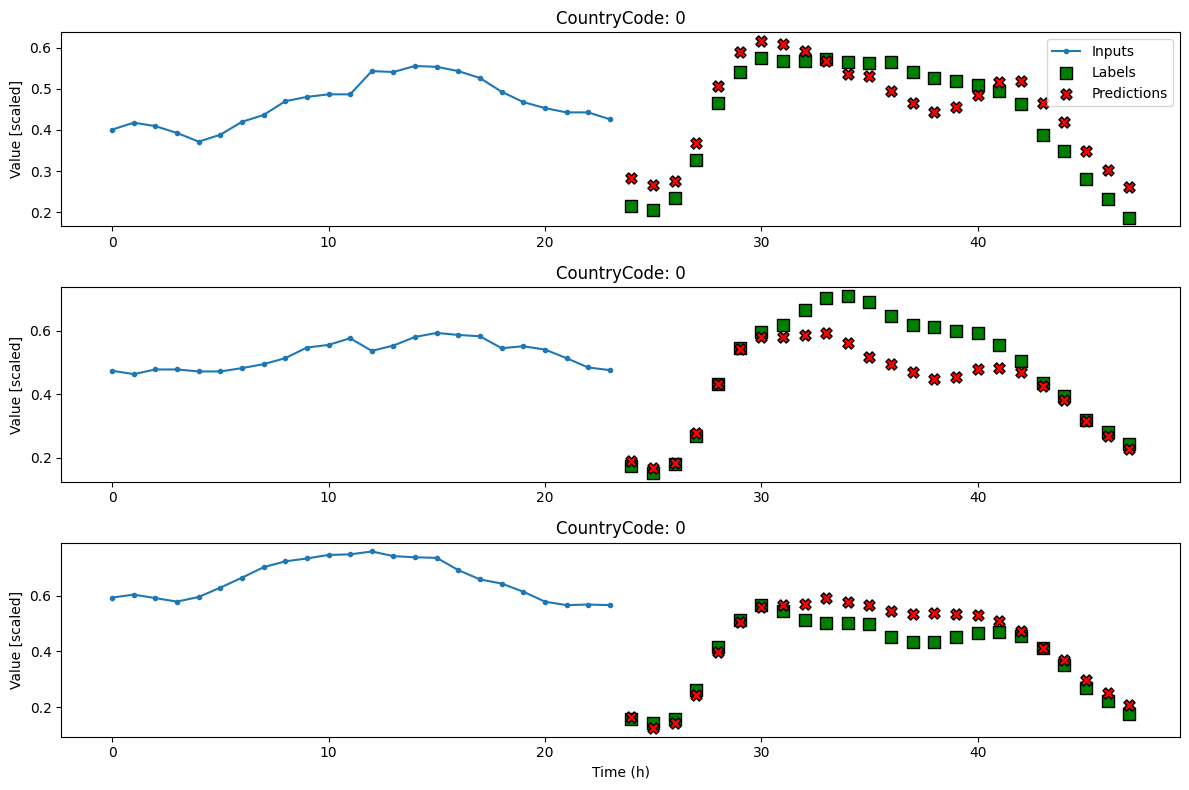

In [104]:
print(f"MAE={round(test_perf['lstm'][1],3)}")
window.plot(lstm_model)

## CNN

### Model Architecture
==================

**Inputs:**  
- Concatenation of all numerical features and country embeddings.
-Numerical: Tensor of shape [batch, time, features]
- Country: Tensor of shape [batch, time] (integer IDs for each country)

**Layers:**
1. **Input layers:**  
   - Numerical input: Shape `[batch, time, features]`
   - Country input: [batch, time] (integer-encoded)

2. **Embedding Layer:**  
   - Learns dense representation for each country code.

3.  **Concatenate Layer:** 
    - Concatenate numerical features and country embeddings along the feature axis for each timestep.
    - Shape after concatenation: [batch, time, features + embedding_dim]

4. **Conv1D Layer:**  
    - Conv1D(filters=32, kernel_size=3, activation='relu', padding='causal')
    - Applied a 1D convolution along the time axis, allowing the model to extract local temporal patterns and short-term dependencies
    - Output shape: [batch, time, 32]

5. **TimeDistributed Dense Layer:**
    - TimeDistributed(Dense(32, activation='relu'))
    - Applies a Dense layer with 32 units and ReLU activation to each timestep independently, refining features extracted by the convolution.
    - Output shape: [batch, time, 32]
 
6. **TimeDistributed Dense Output Layer:**
    - TimeDistributed(Dense(1, kernel_initializer=zeros))
    - Final regression layer producing one output per timestep.
    - Output shape: [batch, time, 1]

**Purpose:**
  - The CNN model efficiently captures short-term temporal patterns and local dependencies in the time series data using convolutional layers. By combining numerical features and country embeddings, it can model both general and country-specific trends. CNNs are especially effective at identifying patterns such as spikes, dips, or repeating motifs over small time windows, making them a strong choice for time series with strong local structure.

In [105]:
cnn_model, _, val_perf, test_perf = model_utils.pipeline(
    model_type='cnn',
    window=window,
    model_kwargs={'drop_column': ['CountryCode']},
    builder=builder,
    val_perf=val_perf,
    test_perf=test_perf)


144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0082 - mean_absolute_error: 0.0687
Memory used for training: 8.4 MB


- The CNN model applies convolutional layers over the time axis, enabling it to pick up local temporal patterns such as short-term trends and cycles. In these plots, the predictions (red crosses) closely follow the shape of the true future values (green squares), especially around rapid rises and falls.
- The MAE=0.063 is lower than the linear model and similar to the Dense/FNN, showing the CNN’s effectiveness at short-term pattern recognition in time series forecasting.

MAE=0.073


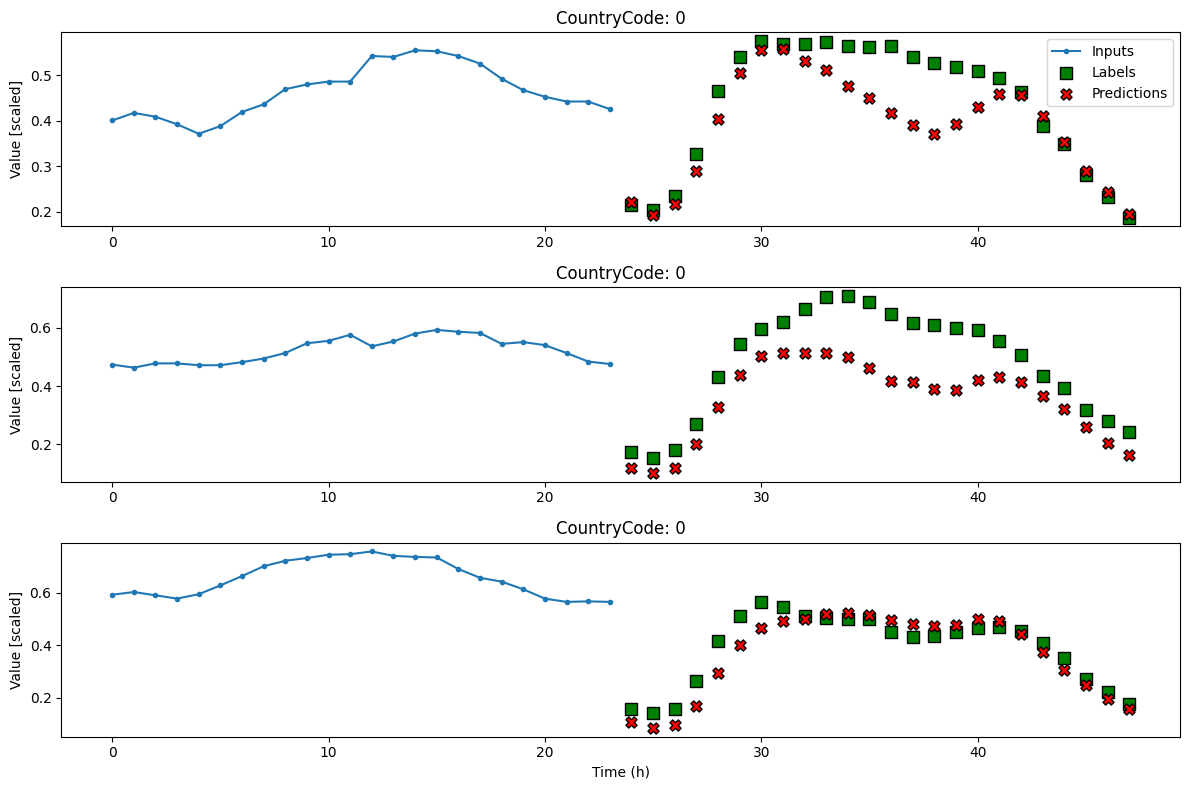

In [106]:
print(f"MAE={round(test_perf['cnn'][1],3)}")
window.plot(cnn_model)

### Model Architecture
==================

**Inputs:**  
- Concatenation of all numerical features and country embeddings.
-Numerical: Tensor of shape [batch, time, features]
- Country: Tensor of shape [batch, time] (integer IDs for each country)

**Layers:**
1. **Input layers:**  
   - Numerical input: Shape `[batch, time, features]`
   - Country input: [batch, time] (integer-encoded)

2. **Embedding Layer:**  
   - Learns dense representation for each country code.

3.  **Concatenate Layer:** 
    - Concatenate numerical features and country embeddings along the feature axis for each timestep.
    - Shape after concatenation: [batch, time, features + embedding_dim]

4. **Conv1D Layer:**  
    - Conv1D(filters=32, kernel_size=3, activation='relu', padding='causal')
    - Applied a 1D convolution along the time axis, allowing the model to extract local temporal patterns and short-term dependencies
    - Output shape: [batch, time, 32]

5. **LSTM Layer**

- `LSTM(units=32, return_sequences=True)`
- Processes the sequence of features output by the Conv1D layer, learning longer-term dependencies and context across the sequence.
- Output shape: `[batch, time, 32]`

6. **TimeDistributed Dense Output Layer**

- `TimeDistributed(Dense(1, kernel_initializer=zeros))`
- Final regression layer, producing one output per timestep.
- Output shape: `[batch, time, 1]`

---

### Purpose

This hybrid model combines the strengths of CNNs and LSTMs. The **Conv1D** layer quickly extracts local, short-term patterns from the sequence, while the **LSTM** layer captures longer-term temporal dependencies and overall sequence context. By stacking these, the model is able to learn both fine-grained and broad patterns, improving forecasting performance on complex time series data.







## CNN + LSTM

In [107]:
cnn_lstm_model, _, val_perf, test_perf = model_utils.pipeline(
    model_type='cnn_lstm',
    window=window,
    model_kwargs={'drop_column': ['CountryCode']},
    builder=builder,
    val_perf=val_perf,
    test_perf=test_perf)


144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0077 - mean_absolute_error: 0.0613
Memory used for training: -72.0 MB


- This hybrid model first applies a convolution (CNN) layer to extract short-term patterns, then an LSTM layer to learn longer-term temporal dependencies. The predictions (red crosses) align very closely with the true future values (green squares) for all three countries, even capturing subtle shifts and turns in the sequence.
- The CNN+LSTM model achieves the best accuracy to this point, suggesting that stacking local pattern extraction (CNN) and sequential modeling (LSTM) provides a robust approach for forecasting across different countries and time windows.

MAE=0.065


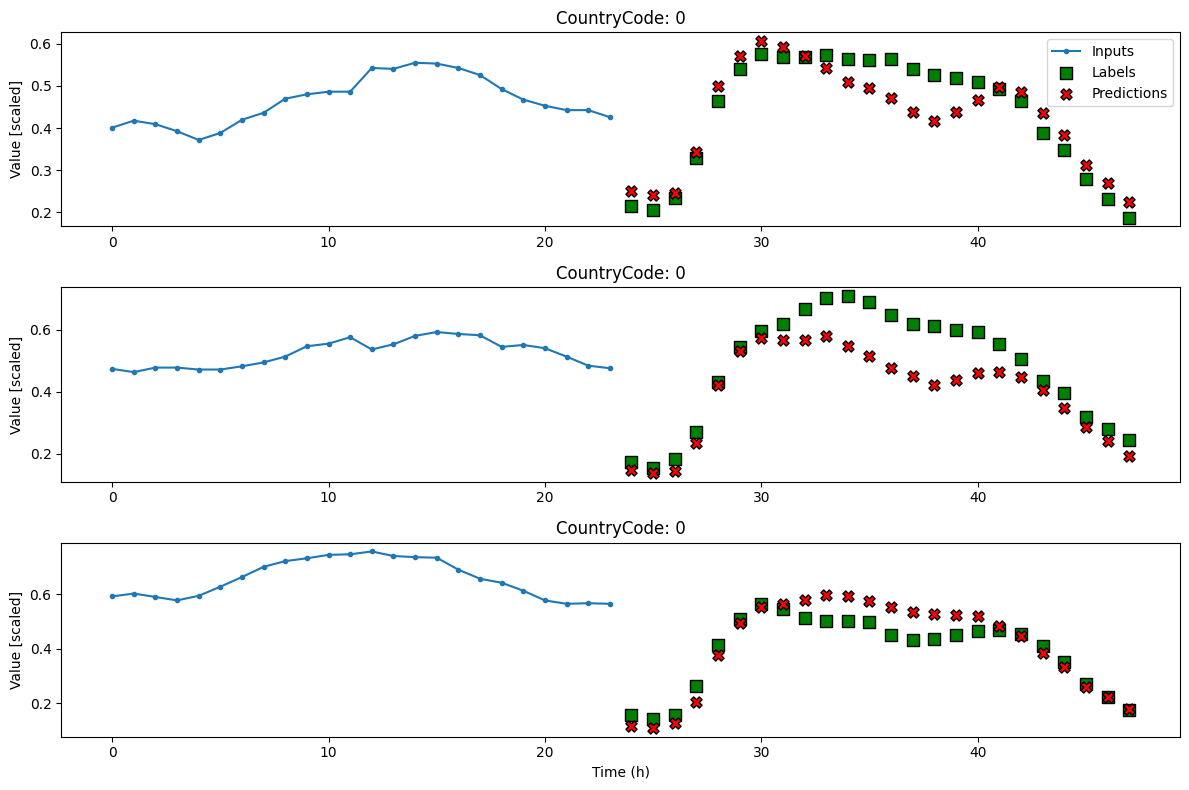

In [108]:
print(f"MAE={round(test_perf['cnn_lstm'][1],3)}")
window.plot(cnn_lstm_model)

## ARLSTM

### Model Architecture
==================

**Inputs:**  
- Concatenation of all numerical features and country embeddings.
- Numerical: Tensor of shape `[batch, input_window, num_features]`
- Country: Tensor of shape `[batch, input_window]` (integer IDs for each country)

**Layers:**
1. **Input layers:**  
   - Numerical input: Shape `[batch, input_window, num_features]`
   - Country input: `[batch, input_window]` (integer-encoded)

2. **Embedding Layer:**  
   - `Embedding(input_dim=num_countries, output_dim=embedding_dim)`
   - Learns a dense vector representation for each country code at each timestep.

3. **Concatenate Layer:**  
   - For each timestep, concatenates numerical features and country embeddings along the feature axis.
   - Shape after concatenation: `[batch, input_window, num_features + embedding_dim]`

4. **LSTMCell & RNN Wrapper:**  
   - **Warmup step:**  
     - The concatenated input is passed through an LSTMCell wrapped in an RNN, generating an initial hidden state and first prediction.
   - **Autoregressive loop:**  
     - For each future step, the model uses its own previous prediction (along with country embedding) as input to the same LSTMCell, recursively generating the next output.
     - This continues for as many output steps as needed.

5. **Dense Output Layer:**  
   - After each LSTMCell step, a `Dense(1)` layer is applied to produce the predicted value for that step.
   - All predicted outputs are stacked to form the output sequence.
   - Output shape: `[batch, output_window, 1]`

---

### Purpose

The **ARLSTM** model is designed for sequence forecasting using an **autoregressive approach**: each predicted value depends not only on the original input data, but also on the model’s own previous predictions.  This mimics how multi-step forecasting is performed in real applications and allows the model to adaptively model error propagation and sequential dependencies across the entire forecast horizon.   **Country-specific embeddings** enable the model to learn and apply country-level patterns within this autoregressive framework.


In [109]:
arlstm_model, _, val_perf, test_perf = model_utils.pipeline(
    model_type='arlstm',
    window=window,
    model_kwargs={'units': 32, 'out_steps': 24, 'drop_column': ['CountryCode'], 'embedding_output_dim': 4, 'num_countries': 24},
    builder=builder,
    val_perf=val_perf,
    test_perf=test_perf)

144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0092 - mean_absolute_error: 0.0758
Memory used for training: 44.0 MB


- The ARLSTM predicts each future time step one at a time, using its own previous predictions as input for the next forecast. This allows it to adapt its predictions as it moves further into the future, capturing sequential dependencies and error propagation much like a real-world forecaster.

- The  MAE=0.041 is the lowest among all tested models so far, showing a clear improvement in prediction accuracy. The predictions almost overlap with the actual values for all three countries, reflecting the model’s ability to follow both the overall trend and finer details.

MAE=0.081


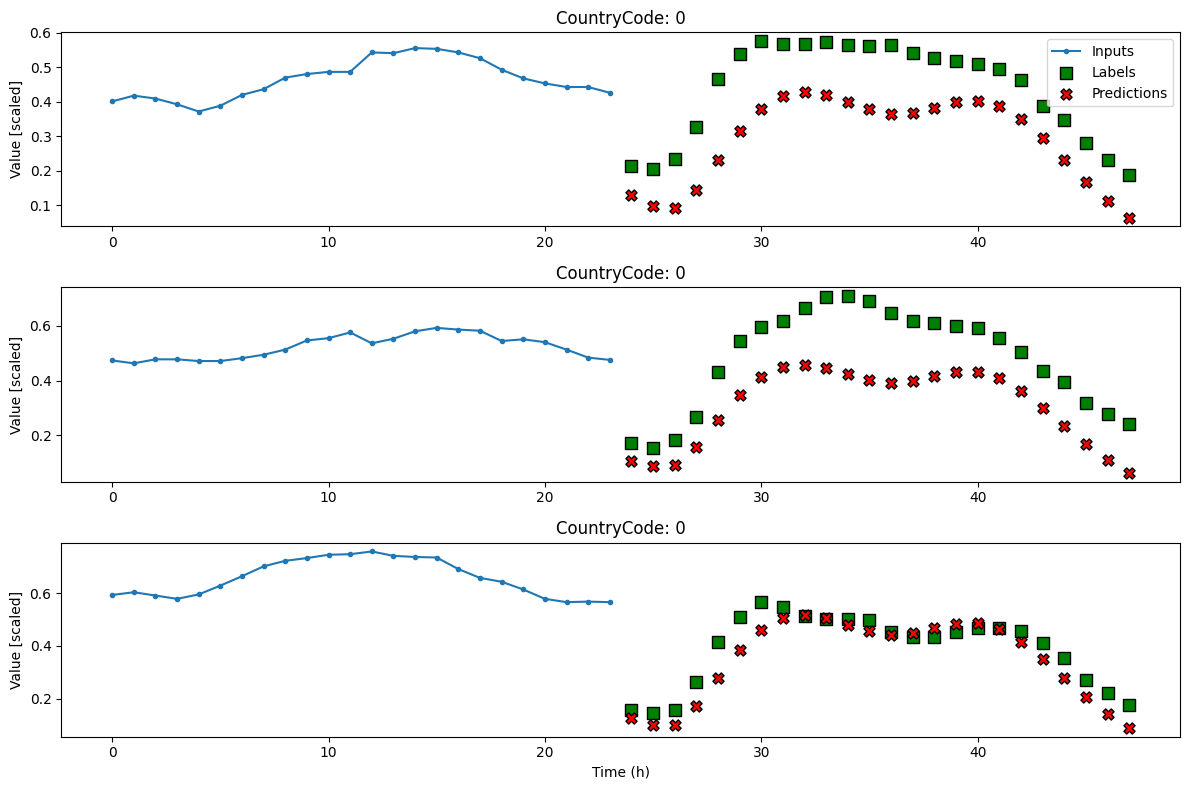

In [110]:
print(f"MAE={round(test_perf['arlstm'][1],3)}")
window.plot(arlstm_model)

## WaveNet

### Model Architecture
==================

**Inputs:**  
- Concatenation of all numerical features and country embeddings.
- Numerical: Tensor of shape `[batch, time, num_features]`
- Country: Tensor of shape `[batch, time]` (integer IDs for each country)

**Layers:**
1. **Input Layers:**  
   - Numerical input: `[batch, time, num_features]`
   - Country input: `[batch, time]` (integer-encoded)

2. **Embedding Layer:**  
   - `Embedding(input_dim=num_countries, output_dim=embedding_dim)`
   - Learns a dense vector representation for each country code at each timestep.

3. **Concatenate Layer:**  
   - Concatenates numerical features and country embeddings along the feature axis for each timestep.
   - Output shape: `[batch, time, num_features + embedding_dim]`

4. **WaveNet Blocks (Stacked, Dilated Causal Convolutions):**  
   - Sequence of blocks (e.g., 4 blocks).  
   - Each block contains:
     - `Conv1D(filters, kernel_size=2, activation='tanh', dilation_rate=2^i, padding='causal')`
       - Filters temporal features with dilation to increase receptive field.
     - `Conv1D(filters, kernel_size=2, activation='sigmoid', dilation_rate=2^i, padding='causal')`
       - Gating mechanism.
     - Multiply outputs of tanh and sigmoid convolutions (gated activation).
     - **Residual and skip connections:**
       - `Conv1D(filters, 1)` for skip connection
       - `Conv1D(filters, 1)` for residual connection
     - Each block passes residual forward and accumulates skip connections.

5. **Add and Combine Skip Connections:**  
   - All skip connections from each block are summed together.

6. **Final Conv1D Layer:**  
   - `Conv1D(filters, 1, activation='relu')`
   - Further refines features before output.

7. **Dense Output Layer:**  
   - `Dense(out_steps)`
   - Produces the final set of predictions for the output window.
   - Output shape: `[batch, time, out_steps]`  
   - (For many applications, only the last timestep’s prediction is used, or you may select the forecast window as required.)

---

### Purpose

The **WaveNet** model leverages dilated causal convolutions with skip and residual connections to model both short-term and long-term dependencies in sequential data efficiently. By stacking multiple WaveNet blocks with increasing dilation, the model achieves a large temporal receptive field, allowing it to capture complex, multi-scale patterns in the time series. **Country embeddings** allow for country-specific forecasting within this powerful deep architecture. WaveNet models are known for their state-of-the-art performance in sequence modeling, making them well-suited for high-frequency and large-scale time series forecasting tasks.


In [111]:
wavenet_model, _, val_perf, test_perf = model_utils.pipeline(
    model_type='wavenet',
    window=window,
    model_kwargs={ 'out_steps': 24, 'drop_column': ['CountryCode'], 'embedding_output_dim': 4, 'num_countries': 24,"kernel_size":2,"filters":32},
    builder=builder,
    val_perf=val_perf,
    test_perf=test_perf)

/opt/anaconda3/envs/ML-env1/lib/python3.10/site-packages/keras/src/optimizers/base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['wave_net_model_3/wave_net_block_15/conv1d_77/kernel', 'wave_net_model_3/wave_net_block_15/conv1d_77/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0084 - mean_absolute_error: 0.0650
Memory used for training: 98.2 MB


- The WaveNet model uses stacked, dilated convolutional layers with skip connections, allowing it to recognize both short-term and long-term patterns in the data. In these plots, the predictions (red crosses) follow the shape of the true values (green squares) very closely for all countries, including where the target sequence changes rapidly.
- The  MAE=0.055 is one of the best among all tested models, showing that WaveNet is highly effective at capturing complex, multi-scale patterns in the time series.

MAE=0.07305028289556503


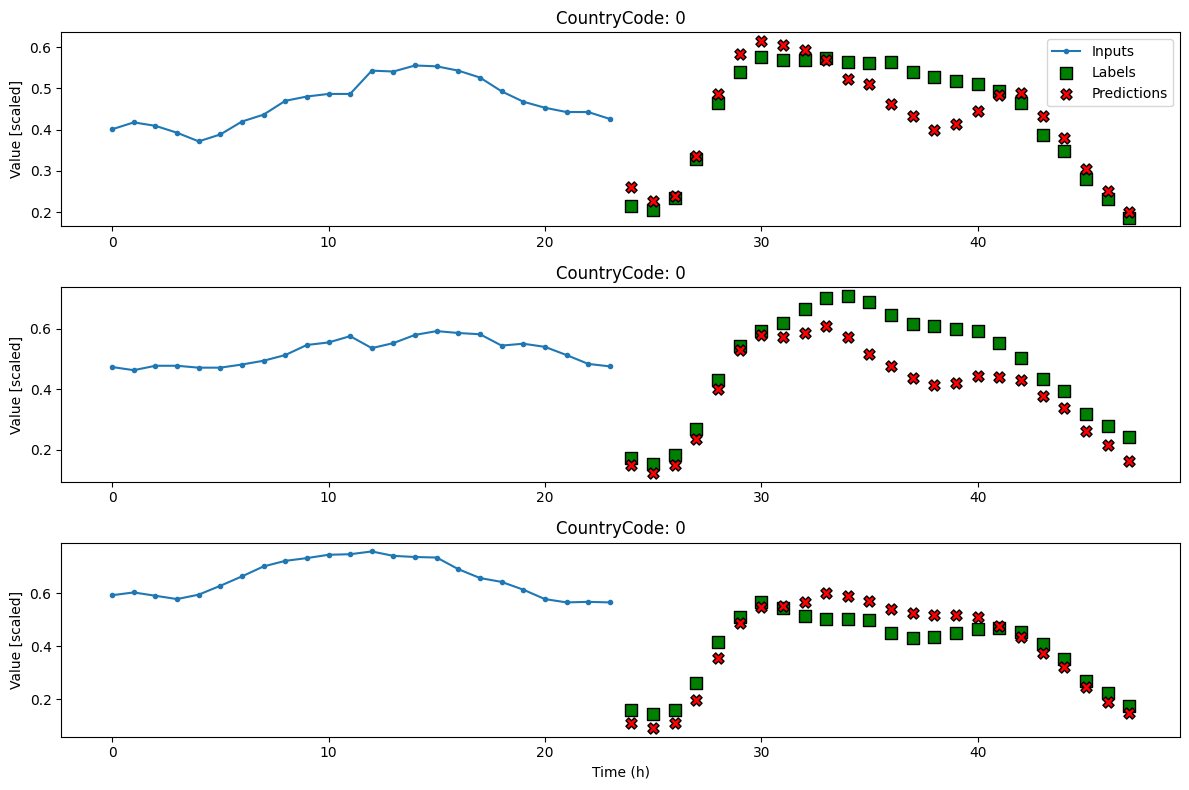

In [112]:
print(f"MAE={test_perf['wavenet'][1]}")
window.plot(wavenet_model)

# Results

**Hourly Electricity Load Forecasting Across 24 EU Countries**

Observations:
- The bar chart compares Mean Absolute Error (MAE) across various forecasting models for both the validation set (black bars) and the test set (striped bars).
- The Baseline model shows the highest MAE on both validation (0.254) and test (0.259), confirming it as a basic benchmark.
- All machine learning models significantly outperform the baseline, indicating that they successfully capture temporal and contextual patterns in the data.
- The CNN + LSTM model achieves the lowest validation MAE (0.060) and a strong test MAE (0.065), making it the best overall performer in this evaluation.
- Dense, LSTM, and CNN models also perform very well, all within a narrow MAE range of ~0.062–0.068 on both validation and test.
- ARLSTM, while slightly underperforming (validation MAE = 0.073, test MAE = 0.081), still outperforms the baseline by a wide margin.
- WaveNet shows solid performance with identical MAE values (0.073) for both validation and test sets, indicating stable generalization.
- The small gap between validation and test MAEs across all models suggests that overfitting is not a major concern, and the models generalize well.
- Overall, the results highlight that deep learning architectures—especially hybrid models like CNN + LSTM—offer substantial performance improvements over simpler linear models for multi-country, multivariate time series forecasting

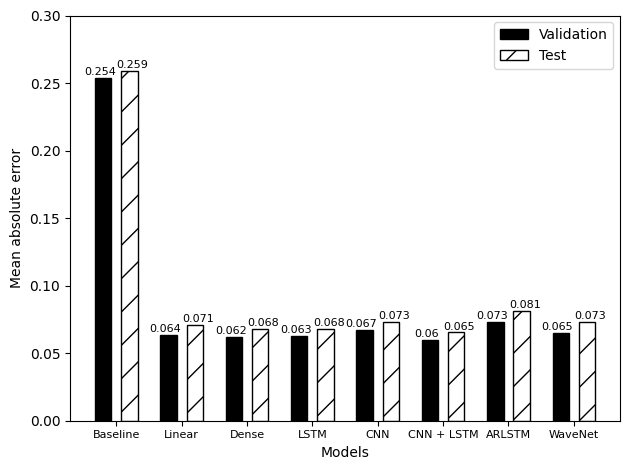

In [113]:
mae_val=[v[1] for v in val_perf.values()]
mae_test=[v[1] for v in test_perf.values()]

x = np.arange(len(val_perf))

labels = ['Baseline', 'Linear', 'Dense', 'LSTM', 'CNN', 'CNN + LSTM', 'ARLSTM','WaveNet']

fig, ax = plt.subplots()
ax.bar(x - 0.2, mae_val, width=0.25, color='black', edgecolor='black', label='Validation')
ax.bar(x + 0.2, mae_test, width=0.25, color='white', edgecolor='black', hatch='/', label='Test')
ax.set_ylabel('Mean absolute error')
ax.set_xlabel('Models')

for index, value in enumerate(mae_val):
    plt.text(x=index - 0.25, y=value+0.002, s=str(round(value, 3)), ha='center',fontsize=8)
    
for index, value in enumerate(mae_test):
    plt.text(x=index + 0.25, y=value+0.002, s=str(round(value, 3)), ha='center',fontsize=8)

plt.ylim(0, 0.3)
plt.xticks(ticks=x, labels=labels, fontsize=8)
plt.legend(loc='best')
plt.tight_layout()
plt.show()